In [127]:
import random
import numpy as np
from numpy.ma.core import sqrt
from scipy.signal import freqz

We begin by defining a function to generate an individual using **Ternary Encoding** or **Mixed Encoding**.

In [128]:
def get_coefficient(n_digits):
    trits = list()
    d_count = 0
    while d_count < n_digits:
        trit = random.choice([1, 0, -1]) 
        if trit != 0:
            d_count += 1
        trits.append(trit)
    return trits


def get_individual(order, n_digits):
    individual = list()
    for _ in range(order):
        individual.append(get_coefficient(n_digits))
    return individual


We also write a function to check the CSD correctness for both encodings.

In [129]:
def CSD_check(individual, n_digits):
    for coeff in individual:
        digit_count = 0
        for digit in coeff:
            if digit != 0:
                digit_count += 1
        if digit_count > n_digits:
            return False
    for coeff in individual:
        for i in range(len(coeff)-1):
            if coeff[i] != 0 and coeff[i+1] != 0:
                return False
    return True
    

We also write a utility to convert from the ternary encoding to a numeric coefficient.

In [130]:
def real_coefficient(coefficient):
    c = 0
    for i in range(len(coefficient)):
        c += coefficient[i] * (2 ** -i)
    return c

We can now write a population initialization function.

In [131]:
def init_population(pop_size, order, n_digits):
    pop = list()
    while len(pop) < pop_size:
        individual = get_individual(order, n_digits)
        #if CSD_check(individual, n_digits):
        pop.append(individual)
    return pop

To perform the mutation, we randomly select a coefficient, and change every trit according to a certain threshold.

In [132]:
def mut(individual):
    p = 0.5
    i = random.randint(0, len(individual)-1)
    for k in range(len(individual[i])):
        if random.random() < p:
            individual[i][k] = random.choice([1, 0, -1])
    return individual

For crossover, we perform a single point crossover between coefficients

In [133]:
def cross(parent1, parent2):
    i = random.randint(1, len(parent1)-1)
    child = parent1[:i] + parent2[i:]
    return child

The fitness function will return the inverse of the minimax error between the individual and the target frequency response. We will use scipy to model a FIR filter after the obtained coefficients

In [134]:
def minimax_error(individual, target):
    wi, Hi = freqz(individual)
    wt, Ht = freqz(target)
    error = max(abs(abs(Ht) - abs(Hi)))
    return error

def lms_error(individual, target):
    wi, Hi = freqz(individual)
    wt, Ht = freqz(target)
    error = sqrt(sum((abs(Ht) - abs(Hi))**2))
    return error

def fitness(individual, target):
    real_individual = [real_coefficient(coef) for coef in individual]
    error = minimax_error(real_individual, target)
    fitness = 1 / error
    return fitness

For selection, we use roulette wheel parent selection.

In [135]:
def roulette_selection(pop, pop_size, target):
    newpop = list()
    while len(newpop) < pop_size:
        total_fitness = sum([fitness(ind, target) for ind in pop])
        pick = random.uniform(0, total_fitness)
        current = 0
        for ind in pop:
            current += fitness(ind, target)
            if current > pick:
                newpop.append(ind)
                break
    return newpop

Now we have all the pieces to implement a simple version of GA.

In [136]:
# Parameters
pop_size = 50
order = 5  # Number of coefficients
n_digits = 3  # Number of non-zero digits per coefficient
target = [-0.1, -0.2, 0.6, -0.2, -0.1]  # Example target coefficients
generations = 100
best = []
# Initialize population
population = init_population(pop_size, order, n_digits)

for _ in range(generations):
    # Selection
    population = roulette_selection(population, pop_size,  target)
    best.append(max(population, key=lambda ind: fitness(ind, target)))
    
    # Crossover and Mutation
    for _ in range(pop_size):
        parent1 = population[random.randint(0, pop_size-1)]
        parent2 = population[random.randint(0, pop_size-1)]
        child1 = cross(parent1, parent2)
        child2 = cross(parent2, parent1)
        population.append(mut(child1))
        population.append(mut(child2))

In [137]:

import matplotlib.pyplot as plt


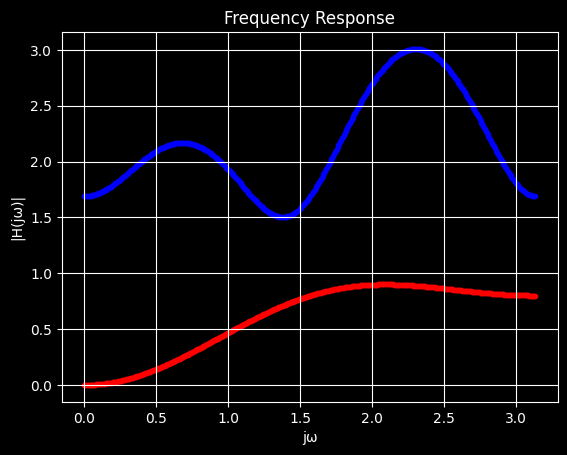

In [139]:

wb, Hb = freqz([real_coefficient(coef) for coef in best[-1]])
wt, Ht = freqz(target)
Hb = abs(Hb)
Ht = abs(Ht)
plt.scatter(wb, Hb, c='blue', marker='.')
plt.scatter(wt, Ht, c='red', marker='.')
plt.xlabel("jω")
plt.ylabel("|H(jω)|")
plt.title("Frequency Response")
plt.grid(True)
plt.show()
